In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


- Atividade dataset Iris com SVM 

In [2]:
# Importação das Bibliotecas 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


# O import "train_test_split" separa um conjunto de dados em subconjuntos de treino e teste de forma aleátoria 
# O "cross_val_score" é uma função que usa validação cruzad para testar a capacidade do modelo, dividindo os dados em várias partes(folds)
# treinando 80% e testando 20%, no final gera um resultados para ver se o modelo é consistente. 
from sklearn.model_selection import train_test_split, cross_val_score
# 
from sklearn.preprocessing import StandardScaler 
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


df_iris = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')

# O "drop" me ajuda excluir a coluna mencionada 
# O "copy" ajuda a manter a copia original do csv intacta 
# Verifica se o Id existe e deleta ele, deletamos a coluna Id para facilitar o tratamento de dados 
if 'Id' in df_iris.columns:
    df_iris_clean = df_iris.drop(columns=['Id'])
else:
    df_iris_clean = df_iris.copy()
# Ler o arquivo 
df_iris_clean.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Descreve as informações da tabela como 150 flores, 6 colunas, todos valores preenchidos e tipo de dados 
df_iris_clean.info()
# O describe me traz o resumo estatístico das variáveis númericas da base de dados
display(df_iris_clean.describe())
# Contagem de cada espécie, e verifica se as classes estão balanceadas 
print(df_iris['Species'].value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


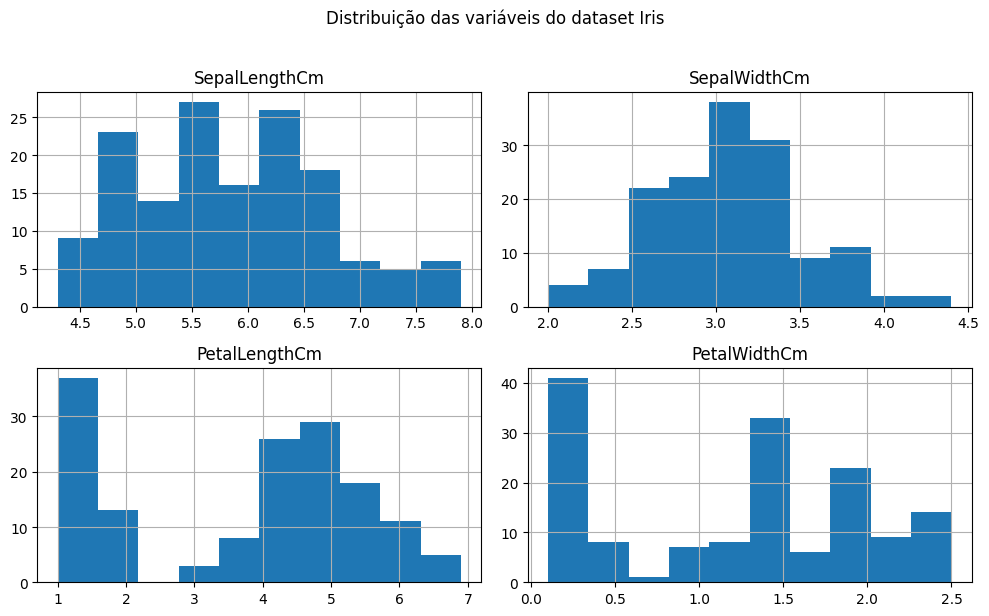

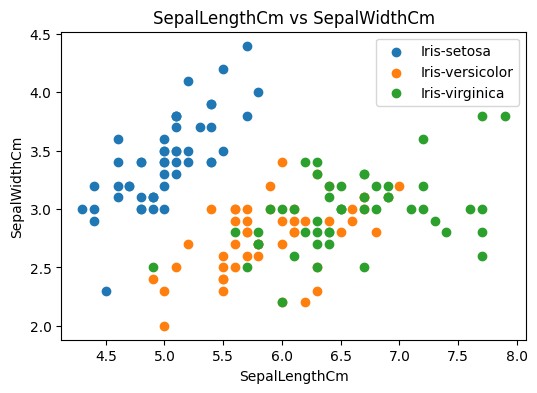

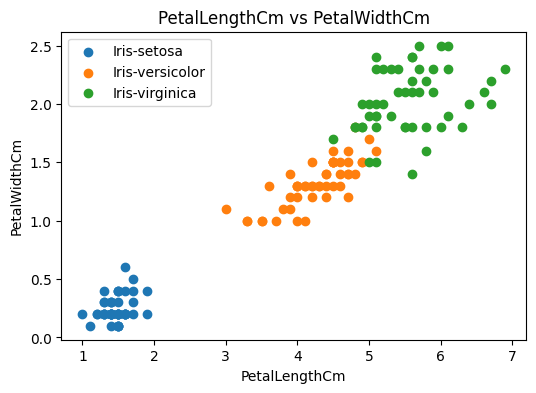

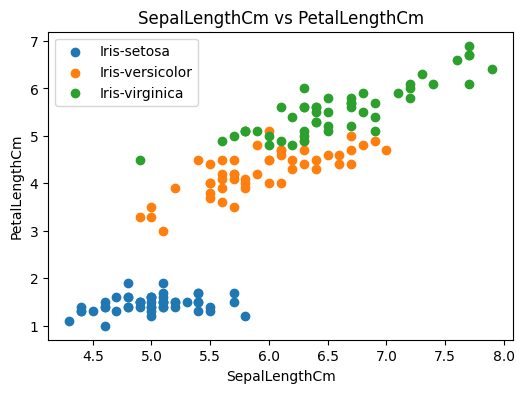

In [4]:
import matplotlib.pyplot as plt 
    
    # Histogramas de Distribuição 
# Removi a coluna espécies para usar só as medidas 
# Hist regula a largura e altura da figura gerada 
df_iris_clean.drop(columns=['Species']).hist(figsize=(10, 6))
plt.suptitle("Distribuição das variáveis do dataset Iris", y=1.02)
# Ajusta o espaçamento entre os eixos, títulos e números 
plt.tight_layout()
plt.show()
# Cria tuplas para o eixo x e y 
pairs = [("SepalLengthCm", "SepalWidthCm"),
         ("PetalLengthCm", "PetalWidthCm"),
         ("SepalLengthCm", "PetalLengthCm")]

for xcol, ycol in pairs: 
    plt.figure(figsize=(6, 4))
    # Loop que pecorre cada espécie única encontrada 
    for species in df_iris_clean["Species"].unique():
        # Filtra o DataFrame para obter a medidada de cada espécie separadamente 
        subset = df_iris_clean[df_iris_clean["Species"] == species]
        plt.scatter(subset[xcol], subset[ycol], label = species)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{xcol} vs {ycol}")
    plt.legend()
    plt.show()

In [5]:

x = df_iris_clean.drop(columns=['Species'])
y = df_iris_clean['Species']
# Exibe a dimensão das tabelas na tela
print("Formato de x:", x.shape)
print("Formato de y:", y.shape)
# Aplica a função do Scikit-Learn que sorteia e divide os dados em quatro subconjuntos:
# atributos de treino (x_train), atributos de teste (x_test), classes de treino (y_train) e classes de teste (y_test).
# "test_size = 0.2" Define a proporção de divisão: 20% dos dados serão reservados para o teste (30 plantas) e os 80% restantes irão para o treino (120 plantas).
# "random_state = 42" Define uma semente aleatória fixa para garantir a reprodutibilidade. Toda vez que o código for executado, o sorteio das amostras será exatamente o mesmo.
# "stratify = y" Aplica uma amostragem estratificada para manter a mesma proporção original das 3 espécies tanto no conjunto de treino quanto no de teste, evitando viés no modelo.
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y 
)

print("X_train:", x_train.shape)
print("X_test.shape", x_test.shape)
print("\nDistribuição em y_train:")
print(y_train.value_counts())
print("\nDistribuição em y_test:")
print(y_test.value_counts())


Formato de x: (150, 4)
Formato de y: (150,)
X_train: (120, 4)
X_test.shape (30, 4)

Distribuição em y_train:
Species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Distribuição em y_test:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


Acurácia do SVM linear: 1.0000
Relatório de classificação — SVM linear

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



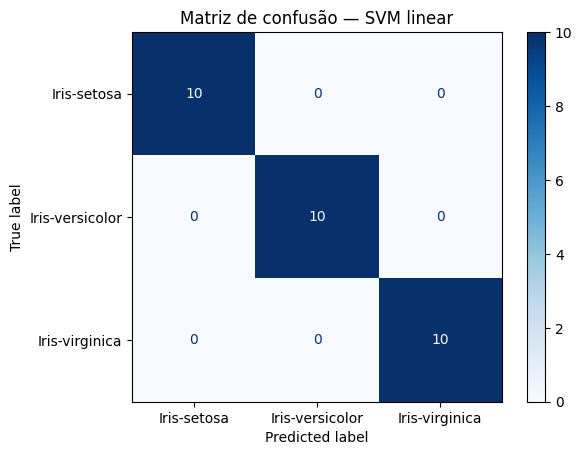

In [6]:
from sklearn.pipeline import Pipeline 
from sklearn.metrics import ConfusionMatrixDisplay 
        # Definição do Pipeline 
# Cria a estrutura do pipeline organizada em duas etapas em "scaler" para aplicar a padronização das variáveis de entrada 
# Usa o SVM com hiperplano reto, regulariza com C= 1.0 que é um valor padrão, busca uma margem maior aceitando um número pequeno de erros no treino 
# O "random_state = 42" garante a mesma reprodutividade em qualquer maquina.
pipeline_svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=42))
])
        # Treinamento e Predição
# Excecução do pipeline, calcula a média e desvio padrão nos dados de treino "x_train"
# padroniza os valores e treina os hiperplano do SVM com as respostas "y_train"
# O "fit" faz o pipeline aprender o padrão de escala dos dados numéricos e aprender as regras geométricas de divisão das espécies de flores com base nas respostas corretas.
pipeline_svm_linear.fit(x_train, y_train)
# Análisa os dados esquecidos e os padroniza com resultados do treino 
y_pred_linear = pipeline_svm_linear.predict(x_test)
# Calcula proporção de acertos do modelo comparando o vetor real de respostas (y_test) com as predições (y_pred_linear).
acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Acurácia do SVM linear: {acc_linear:.4f}")
# Exibe Precisão, Revocação e Média entre precisão e revocação 
print("Relatório de classificação — SVM linear\n")
print(classification_report(y_test, y_pred_linear))
     # Matriz Confusão
# Extrai a lista com as classes únicas aprendidas pelo modelo ('Iris-setosa', 'Iris-versicolor', 'Iris-virginica') na ordem correta.
classes_iris = pipeline_svm_linear.classes_
# Gera a matriz numérica cruzando as classes reais contra as predições do modelo para identificar onde ocorreram acertos (diagonal principal) e possíveis erros.
cm_linear = confusion_matrix(y_test, y_pred_linear, labels=classes_iris)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=classes_iris)

disp.plot(cmap="Blues")
plt.title("Matriz de confusão — SVM linear")
plt.show()


In [7]:
# Usamos validação cruzada para provar que SVM trabalha bem para todo o dataset 
# Aplica a validação cruzada, onde o parâmetro cv=5 divide o dataset (x, y) em 5 blocos 
# iguais de 30 amostras. O algoritmo executa o pipeline 5 vezes, 4 treino e 1 teste, garantindo que todos os dados sejam testados
scores_linear = cross_val_score(pipeline_svm_linear, x, y, cv=5)

print("Acurácia em cada fold:", scores_linear)
print(f"Média: {scores_linear.mean():.4f}")
print(f"Desvio-padrão: {scores_linear.std():.4f}")

Acurácia em cada fold: [0.96666667 1.         0.93333333 0.93333333 1.        ]
Média: 0.9667
Desvio-padrão: 0.0298


- Não Linear


Acurácia do SVM Não Linear (RBF): 0.9667

Relatório de Classificação — SVM Não Linear (RBF)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



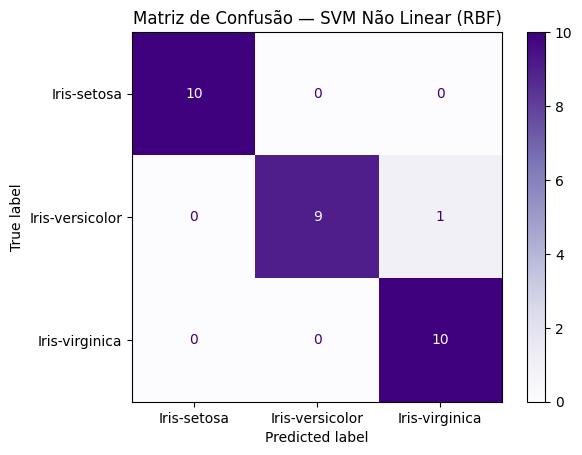

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# O "rbf" Define a função de base radial (Radial Basis Function), que cria fronteiras de decisão curvas e circulares para separar classes que não podem ser divididas por uma linha reta.
# O "gamma" define o alcance de influência de cada ponto, "scale" ajusta esse alcance com base na variância
# Pipeline com SVM Não Linear (Kernel RBF)
pipeline_svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

# Treinamento
pipeline_svm_rbf.fit(x_train, y_train)

# Predição
y_pred_rbf = pipeline_svm_rbf.predict(x_test)

# Avaliação das Métricas
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Acurácia do SVM Não Linear (RBF): {acc_rbf:.4f}\n")

print("Relatório de Classificação — SVM Não Linear (RBF)\n")
print(classification_report(y_test, y_pred_rbf))

# Matriz de Confusão
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=pipeline_svm_rbf.classes_)

disp_rbf.plot(cmap="Purples")
plt.title("Matriz de Confusão — SVM Não Linear (RBF)")
plt.show()